### Step 1: Import Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.utils import to_categorical

In [2]:
import matplotlib.pyplot as plt
import numpy as np

### Step 2: Load CIFAR-10 Dataset

In [7]:
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

In [23]:
X_train.shape

(50000, 32, 32, 3)

In [8]:
print('data type:', X_train.dtype, 'max:', X_train.max(), 'min:', X_train.min())

data type: uint8 max: 255 min: 0


In [9]:
print('label type:', y_train.dtype, 'max:', y_train.max(), 'min:', y_train.min())

label type: uint8 max: 9 min: 0


### Step 3: Preprocess Data

In [10]:
X_train = X_train.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

In [11]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

### Step 4: Visualize Sample Images

In [12]:
class_names = ['Airplane','Automobile','Bird','Cat','Deer','Dog','Frog','Horse','Ship','Truck']

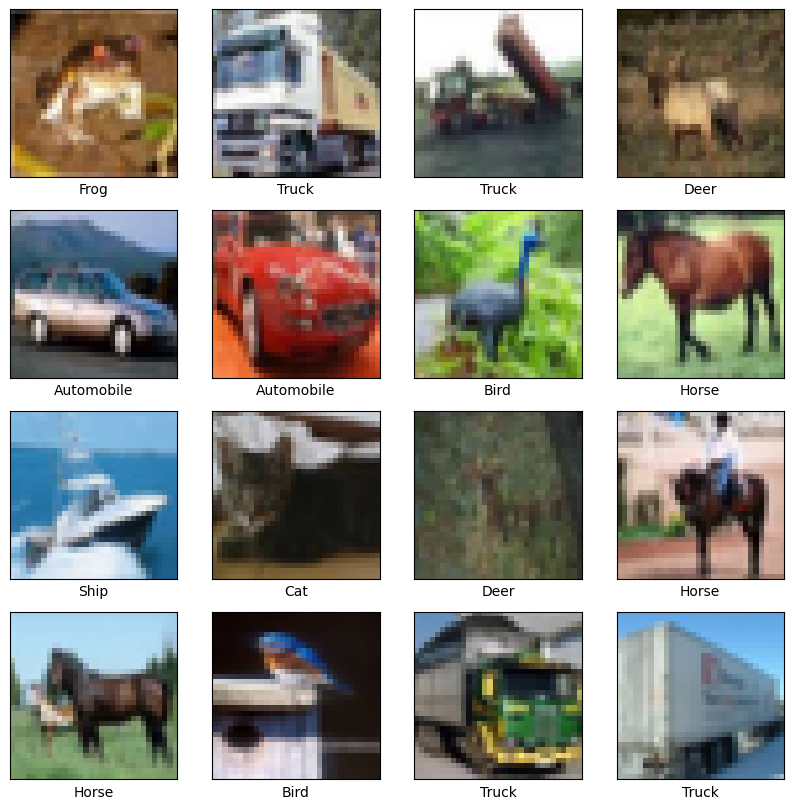

In [13]:
fig, ax = plt.subplots(4, 4, figsize=(10, 10))
for i in range(4):
    for j in range(4):
        ax[i][j].set_xticks([])
        ax[i][j].set_yticks([])
        ax[i][j].imshow(X_train[i*4+j])
        ax[i][j].set_xlabel(class_names[np.argmax(y_train[i*4+j])])

### Step 5: Build the CNN Model

In [66]:
class CNN(tf.keras.Model):
    def __init__(self):
        super().__init__(name='CNN')
        self.conv1 = layers.Conv2D(32, 3, activation='relu', padding='same')
        self.conv2 = layers.Conv2D(32, 3, activation='relu', padding='same')

        self.conv3 = layers.Conv2D(64, 3, activation='relu', padding='same')
        self.conv4 = layers.Conv2D(64, 3, activation='relu', padding='same')

        self.conv5 = layers.Conv2D(128, 3, activation='relu', padding='same')
        self.conv6 = layers.Conv2D(128, 3, activation='relu', padding='same')

        self.flatten = layers.Flatten()
        self.dense = layers.Dense(512, activation='relu')
        self.out = layers.Dense(10, activation='softmax')

        self.maxpool = layers.MaxPool2D()
        self.dropout = layers.Dropout(0.25)
        self.dropout_fc = layers.Dropout(0.5)

    def call(self, x, training=False):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.maxpool(x)
        x = self.dropout(x, training=training)

        x = self.conv3(x)
        x = self.conv4(x)
        x = self.maxpool(x)
        x = self.dropout(x, training=training)

        x = self.conv5(x)
        x = self.conv6(x)
        x = self.maxpool(x)
        x = self.dropout(x, training=training)

        x = self.flatten(x)
        x = self.dense(x)
        x = self.dropout_fc(x, training=training)
        x = self.out(x)
        return x

In [67]:
model = CNN()

### Step 6: Compile the Model

In [63]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# model.compile(
#     optimizer=tf.keras.optimizers.Adam(),
#     loss=tf.keras.losses.CategoricalCrossentropy(),
#     metrics=[tf.keras.metrics.CategoricalAccuracy()]
# )

In [46]:
_ = model(tf.random.normal([1, 32, 32, 3]))

In [47]:
model.summary()

Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)                   │ (1, 32, 32, 32)             │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_25 (Conv2D)                   │ (1, 32, 32, 32)             │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_26 (Conv2D)                   │ (1, 16, 16, 64)             │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_27 (Conv2D)                   │ (1, 16, 16, 64)             │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_28 (Conv2D)                   │ (1, 8, 8, 128)              │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_29 (Conv2D)                   │ (1, 8, 8, 128)              │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (1, 2048)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (1, 512)                    │       1,049,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (1, 10)                     │           5,130 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ ?                           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,341,226 (5.12 MB)

 Trainable params: 1,341,226 (5.12 MB)

 Non-trainable params: 0 (0.00 B)

### Step 7: Train the Model

In [69]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - categorical_accuracy: 0.3526 - loss: 1.7356 - val_categorical_accuracy: 0.4994 - val_loss: 1.3573
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - categorical_accuracy: 0.5310 - loss: 1.2924 - val_categorical_accuracy: 0.6125 - val_loss: 1.0911
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - categorical_accuracy: 0.6091 - loss: 1.0977 - val_categorical_accuracy: 0.6455 - val_loss: 0.9866
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - categorical_accuracy: 0.6593 - loss: 0.9674 - val_categorical_accuracy: 0.7073 - val_loss: 0.8346
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - categorical_accuracy: 0.6893 - loss: 0.8843 - val_categorical_accuracy: 0.7145 - val_loss: 0.8042
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - categorical_accuracy: 0.7104 - loss: 0.8242 - val_categorical_accuracy: 0.7245 - val_loss: 0.7944
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - categorical_accuracy

### Step 8: Plot Training History

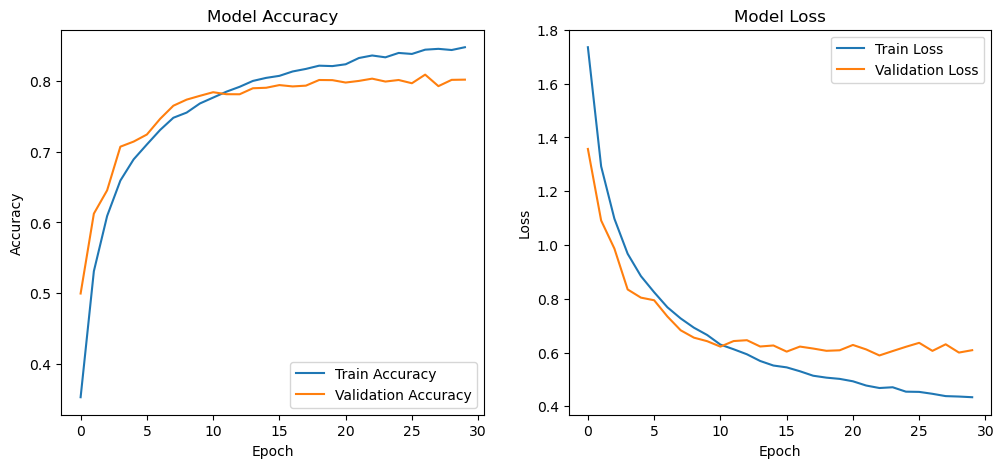

In [75]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['categorical_accuracy'], label='Train Accuracy')
plt.plot(history.history['val_categorical_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

### Step 9: Predict on Test Images

In [92]:
def plot_predictions(index):
    img = X_test[index]
    true_label = class_names[np.argmax(y_test[index])]
    pred_probs = model.predict(np.expand_dims(img, axis=0))
    pred_label = class_names[np.argmax(pred_probs)]
    
    plt.imshow(img)
    plt.title(f"True: {true_label} | Pred: {pred_label}")
    plt.axis('off')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


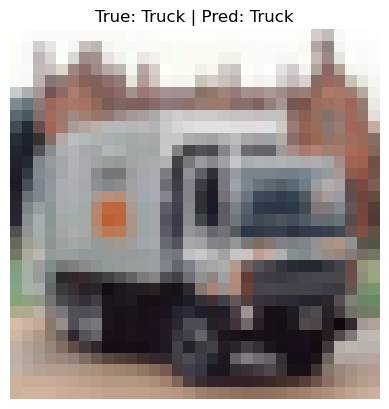

In [91]:
plot_predictions(11)